# Train Multiple Linear Regression — Baseline Comparison

Trains a logistic regression model as a simpler baseline for churn prediction.
Compares against XGBoost to answer: **is the non-linear model worth the complexity?**

If MLR gets within 5 AUC points of XGBoost, the simpler model wins on interpretability.
If XGBoost dominates, the non-linear interactions are real signal.

In [1]:
import json
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../backend/src')
from nodes.feature_engineer import engineer_features
from nodes.nn_retrieval import features_to_vector, FEATURE_COLUMNS

sns.set_style('whitegrid')

## Load Data

In [2]:
deal_files = sorted(glob.glob('../backend/data/synthetic/DEAL-*.json'))
print(f'Found {len(deal_files)} deals')

deals = []
features_list = []
labels = []

for f_path in deal_files:
    with open(f_path) as f:
        deal = json.load(f)
    deals.append(deal)
    features_list.append(engineer_features(deal))
    labels.append(1 if deal['outcome']['status'] == 'churned' else 0)

X = np.array([features_to_vector(f) for f in features_list])
y = np.array(labels)

print(f'Matrix: {X.shape}')
print(f'Churn rate: {y.mean():.1%}')

Found 990 deals
Matrix: (990, 54)
Churn rate: 15.7%


## Train/Val/Test Split (same as XGBoost for fair comparison)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# Logistic regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 692 | Val: 149 | Test: 149


## Train Logistic Regression

Logistic regression = "multiple linear regression" for binary classification.
It's the right linear baseline since our target (churn) is binary.

In [4]:
from sklearn.linear_model import LogisticRegression

# L2 regularization, class-weighted for imbalanced data
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)

model.fit(X_train_scaled, y_train)

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Train AUC: {roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1]):.3f}')
print(f'Val AUC:   {roc_auc_score(y_val, y_val_prob):.3f}')
print(f'Test AUC:  {roc_auc_score(y_test, y_test_prob):.3f}')

print(f'\n--- Test classification report ---')
y_test_pred = (y_test_prob > 0.5).astype(int)
print(classification_report(y_test, y_test_pred, target_names=['retained', 'churned'], zero_division=0))

Train AUC: 0.803
Val AUC:   0.622
Test AUC:  0.605

--- Test classification report ---
              precision    recall  f1-score   support

    retained       0.88      0.67      0.76       126
     churned       0.22      0.52      0.31        23

    accuracy                           0.64       149
   macro avg       0.55      0.59      0.54       149
weighted avg       0.78      0.64      0.69       149



## Feature Coefficients — Global Importance

Unlike SHAP, logistic regression gives you coefficients directly.
Positive coefficient = feature increases churn risk.
Negative coefficient = feature reduces churn risk.

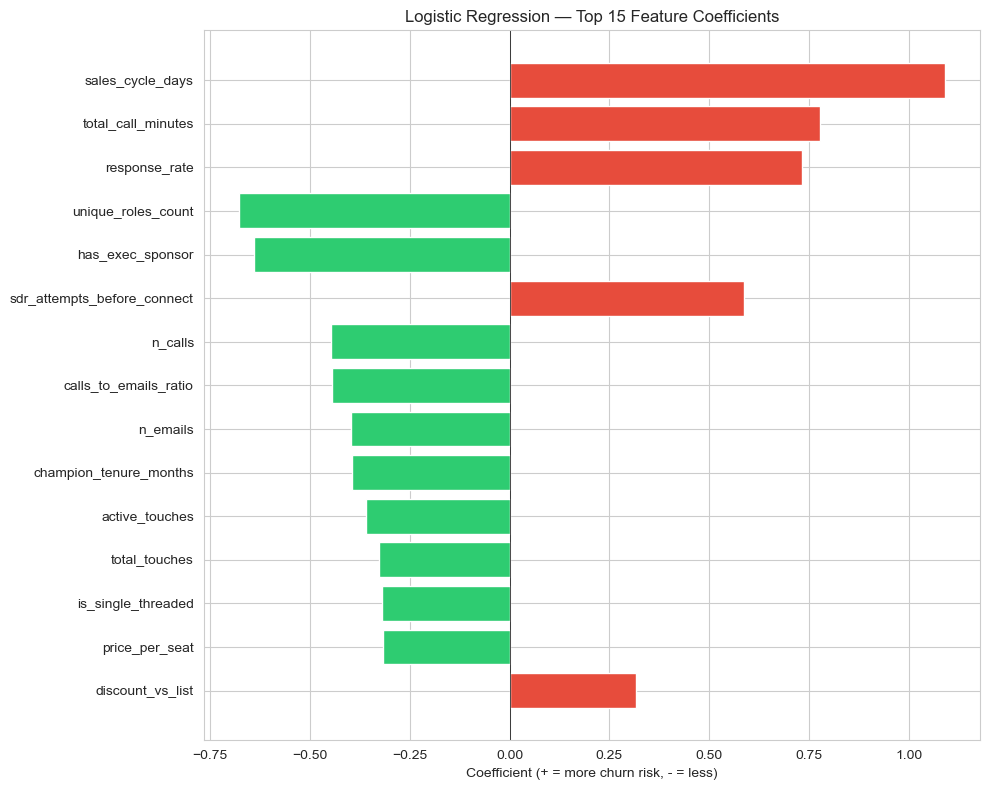

In [5]:
coefficients = pd.Series(model.coef_[0], index=FEATURE_COLUMNS)
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=True).index)

top_15 = coefficients_sorted.tail(15)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_15.values]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_15.index, top_15.values, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Logistic Regression — Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient (+ = more churn risk, - = less)')
plt.tight_layout()
plt.show()

## Compare Against XGBoost

In [6]:
# Load the XGBoost model trained in notebook 02
import pickle
with open('../backend/data/models/xgb/model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Score same test set with XGBoost (XGB uses raw features, not scaled)
y_test_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_mlr = y_test_prob

print(f'Test AUC comparison:')
print(f'  MLR (Logistic Regression): {roc_auc_score(y_test, y_test_mlr):.3f}')
print(f'  XGBoost:                   {roc_auc_score(y_test, y_test_xgb):.3f}')
print(f'  Gap: {abs(roc_auc_score(y_test, y_test_xgb) - roc_auc_score(y_test, y_test_mlr)):.3f}')

Test AUC comparison:
  MLR (Logistic Regression): 0.605
  XGBoost:                   0.621
  Gap: 0.017


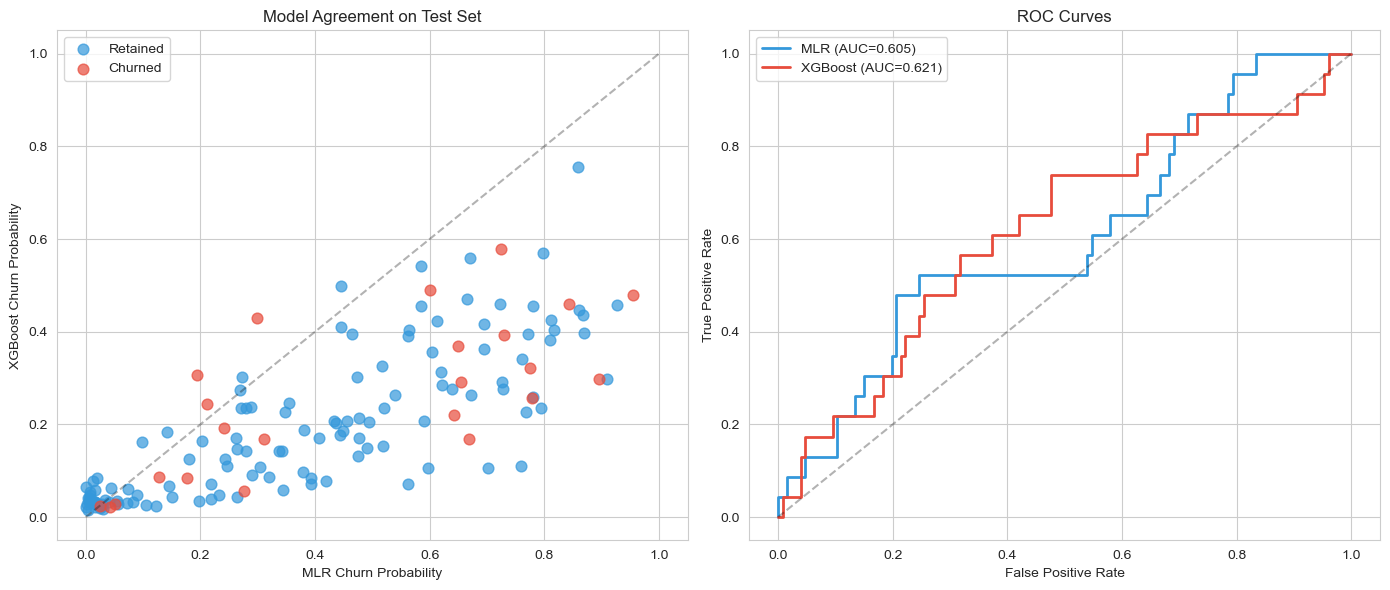

In [7]:
# Agreement plot — do both models flag the same deals?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: MLR prob vs XGB prob, colored by actual outcome
colors_map = {0: '#3498db', 1: '#e74c3c'}
for label, name in [(0, 'Retained'), (1, 'Churned')]:
    mask = y_test == label
    axes[0].scatter(y_test_mlr[mask], y_test_xgb[mask], 
                    c=colors_map[label], label=name, alpha=0.7, s=60)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('MLR Churn Probability')
axes[0].set_ylabel('XGBoost Churn Probability')
axes[0].set_title('Model Agreement on Test Set')
axes[0].legend()

# ROC curves
from sklearn.metrics import roc_curve
fpr_mlr, tpr_mlr, _ = roc_curve(y_test, y_test_mlr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_xgb)
axes[1].plot(fpr_mlr, tpr_mlr, label=f'MLR (AUC={roc_auc_score(y_test, y_test_mlr):.3f})', color='#3498db', linewidth=2)
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_test_xgb):.3f})', color='#e74c3c', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.show()